# Chapter 11 - Machine learning from scratch

*This notebook contains all the sample code in Chapter 11.*

## Outline

- [Regression](#Regression)
- [Classification](#Classification)
    - [K-Nearest Neighbors](#knn)
    - [Logistic regression](#LR)
    - [Perceptron and Adaline](#Perceptron)
    - [Single-layer perceptron](#SLP)
    - [Multilayer perceptron](#MLP)
    - [Support Vector Machines](#SVM)

## Regression <a id="Regression"></a>

A **regression** problem consists of modeling the relationship between a *real-valued* target variable $d$ and a set of $M$ explanatory variables $x_1,x_2,\ldots,x_M$. These variables are collected in the feature vector $\mathbf{x} = [x_1,x_2,\ldots,x_M]^\top$. 

A general regression model can be written as:
$$
d = f_{\boldsymbol{\theta}}(\mathbf{x}) + v,
$$
where $r = f_{\boldsymbol{\theta}}(\cdot)$ is a function parameterized by the unknown vector $\boldsymbol{\theta}$ and $v$ represents measurement noise or modeling error.

Given a training set $\mathcal{T}=\{(\mathbf{x}_n,d_n)\}_{n=1}^{N}$, the objective is to estimate a model $\mathbf{w}$ that predicts the target associated with a previously unseen input. The vector $\mathbf{x}_n$ is also called a **regressor**, while $d_n$ is the desired output or target.

The solution is:
$$
\mathbf{w} = \left(\mathbf{X}^\top\mathbf{X}\right)^{-1}\mathbf{X}^\top\mathbf{d} \equiv \mathbf{X}^{+}\mathbf{d}.
$$

In [1]:
import numpy as np

def linear_regression_ls(X, y):
    """Return the least-squares parameters [bias, coefficients]."""
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    X_aug = np.column_stack((np.ones(X.shape[0]), X))
    w, _, _, _ = np.linalg.lstsq(X_aug, y, rcond=None)
    # w = np.dot(np.dot(np.linalg.inv(np.dot(X_aug.T, X_aug)), X_aug.T), y)
    return w

This function is used with the following synthetic dataset:

[-1.23134107  2.01207601]


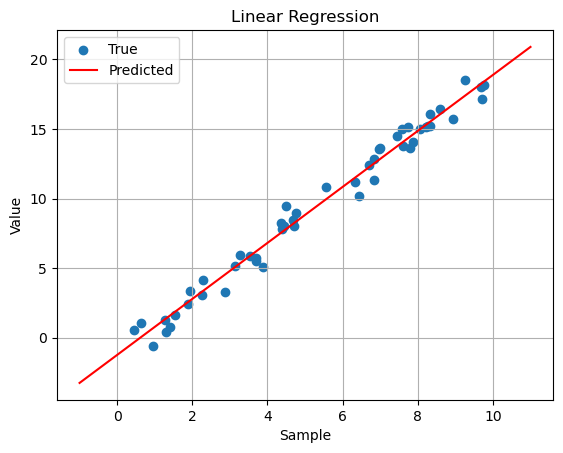

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 50
rng = np.random.default_rng(42)

x_train = 10.0 * rng.random(N)
y_train = 2.0 * x_train - 1.0 + rng.standard_normal(N)
X_train = x_train[:, np.newaxis]


# Estimate weights
w = linear_regression_ls(X_train, y_train)
print(w)


# Predict new data
x_test = np.linspace(-1.0, 11.0, 100)
X_test = x_test[:, np.newaxis]

y_pred = w[0] + w[1] * x_test 


# Plot original and predicted data
plt.figure()
plt.scatter(x_train, y_train, label='True')
plt.plot(x_test, y_pred, color='red', label='Predicted')
plt.grid()
plt.title('Linear Regression')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()

An alternative is to minimize the loss iteratively: $\mathbf{w}_{n+1} = \mathbf{w}_n - \partial \overline{\mathcal{L}} / \partial \mathbf{w}_n$. For the average squared-error loss:
$$
\overline{\mathcal{L}}(\widetilde{\mathbf{w}}) = \frac{1}{2N}\sum_{n=1}^{N}(d_n-y_n)^2,
$$
the negative gradient with respect to the $m$-th coefficient is:
$$
-\frac{\partial \overline{\mathcal{L}}}{\partial w_m} = \frac{1}{N}\sum_{n=1}^{N}(d_n-y_n)x_{nm},
$$
while the bias update uses $x_{n0}=1$. A simple batch-gradient implementation is:

In [3]:
class LinearRegression:
    """Linear regression trained by batch gradient descent."""

    def __init__(self, eta=0.01, n_iter=200):
        self.eta = eta
        self.n_iter = n_iter

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        self.loss_ = []
        n_samples = X.shape[0]

        for _ in range(self.n_iter):
            prediction = self.predict(X)
            error = y - prediction

            self.w_ += self.eta * (X.T @ error) / n_samples
            self.b_ += self.eta * error.mean()
            self.loss_.append(0.5 * np.mean(error**2))

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

The class can be used as follows:

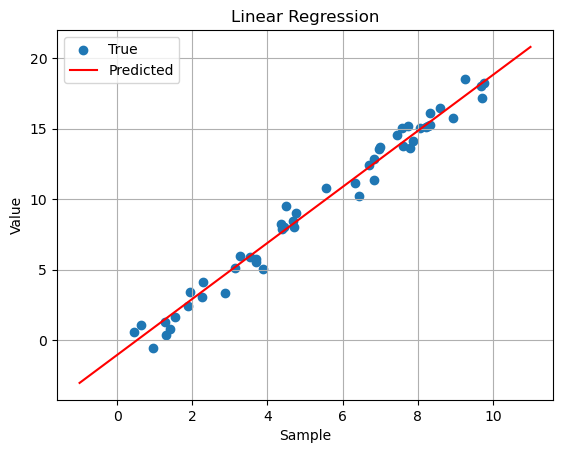

In [4]:
N = 50
rng = np.random.default_rng(42)

x_train = 10.0 * rng.random(N)
y_train = 2.0 * x_train - 1.0 + rng.standard_normal(N)
X_train = x_train[:, np.newaxis]

x_test = np.linspace(-1.0, 11.0, 100)
X_test = x_test[:, np.newaxis]

# Use the Linear Regression class
lr = LinearRegression(eta=0.02, n_iter=500)
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

# Plot original and predicted data
plt.figure()
plt.scatter(x_train, y_train, label='True')
plt.plot(x_test, y_pred, color='red', label='Predicted')
plt.grid()
plt.title('Linear Regression')
plt.xlabel('Sample')
plt.ylabel('Value')
plt.legend()

## Classification <a id="Classification"></a>

**Classification** algorithms assign an input vector to one of a finite set of classes.

To illustrate the algorithms, we use two datasets. The first is the **Palmer Penguins** dataset, available through the Seaborn library. It contains measurements of three penguin species (*Adelie*, *Chinstrap*, and *Gentoo*) including bill length, bill depth, flipper length, and body mass.

In [5]:
import numpy as np
from seaborn import load_dataset

rng = np.random.default_rng(42)
data = load_dataset("penguins")
columns = [
    "species",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

data = data[columns].dropna()
idx = rng.permutation(len(data))
data = data.iloc[idx].reset_index(drop=True)

X = data.iloc[:, 1:].to_numpy(dtype=float)
label_map = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
y = data["species"].map(label_map).to_numpy(dtype=int)

n_train = int(0.67 * len(data))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]

The second dataset is the **Optical Recognition of Handwritten Digits** dataset. Each observation is an $8\times8$ *gray-scale* image represented by a vector of 64 pixel values.

In [6]:
import pandas as pd

data_train = pd.read_csv("../data/optdigits.tra", header=None)
X_train = data_train.iloc[:, :64].to_numpy(dtype=float)
y_train = data_train.iloc[:, 64].to_numpy(dtype=int)

data_test = pd.read_csv("../data/optdigits.tes", header=None)
X_test = data_test.iloc[:, :64].to_numpy(dtype=float)
y_test = data_test.iloc[:, 64].to_numpy(dtype=int)

A *feature vector* can be **reshaped** to recover its original image. We show nine randomly selected training examples:

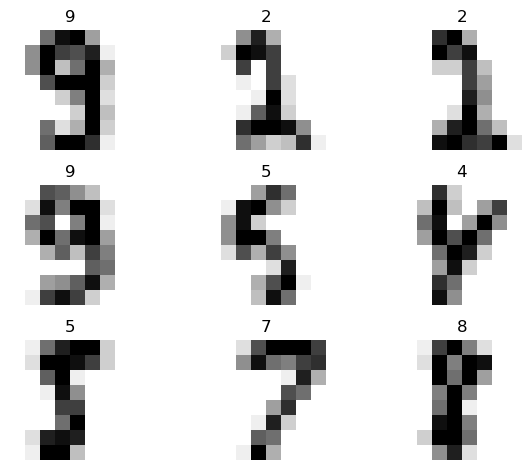

In [7]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
indices = rng.choice(len(X_train), size=9, replace=False)
fig, axes = plt.subplots(3, 3)

for ax, k in zip(axes.ravel(), indices):
    ax.imshow(X_train[k].reshape(8, 8), cmap="binary")
    ax.set_title(str(y_train[k]))
    ax.axis("off")

fig.tight_layout()

For **binary-classification** experiments, the ten digit classes can be grouped into digits smaller than 5 and digits greater than or equal to 5:

In [8]:
y_train_binary = np.where(y_train < 5, 0, 1)
y_test_binary = np.where(y_test < 5, 0, 1)

### K-Nearest Neighbors <a id="knn"></a>

Let $\mathcal{T}=\{(\mathbf{x}_j,y_j)\}_{j=1}^{N}$ be a labeled training set. Given a query vector $\mathbf{x}_q$, the $k$-**nearest neighbors** ($k$NN) algorithm finds the $k$ training samples closest to $\mathbf{x}_q$ and assigns the most frequent class among those neighbors. The value of $k$ controls the locality of the decision.

If $\mathcal{N}_k(\mathbf{x}_q)$ denotes the indices of the $k$ nearest samples, the predicted class is:
$$
\widehat{y} = \operatorname*{arg\,max}_{c\in\mathcal{Y}} \sum_{i\in\mathcal{N}_k(\mathbf{x}_q)} \delta(c,y_i),
$$
where $\mathcal{Y}$ is the set of class labels and
$$
\delta(a,b)=\begin{cases}
1, & a=b,\\
0, & a\neq b.
\end{cases}
$$
The result depends strongly on the distance measure. Common distances for continuous-valued features include:
1. **Euclidean** distance:
$$
d(\mathbf{x}_i,\mathbf{x}_j) = \sqrt{\sum_{m=1}^{M}(x_{im}-x_{jm})^2}.
$$
2. **Manhattan** or **city-block** distance:
$$
d(\mathbf{x}_i,\mathbf{x}_j) = \sum_{m=1}^{M}|x_{im}-x_{jm}|.
$$
3. **Minkowski** distance:
$$
d(\mathbf{x}_i,\mathbf{x}_j) = \left(\sum_{m=1}^{M}|x_{im}-x_{jm}|^p\right)^{1/p}.
$$
In distance-weighted $k$NN, closer neighbors receive larger weights:
$$
\widehat{y} = \operatorname*{arg\,max}_{c\in\mathcal{Y}}
\sum_{i\in\mathcal{N}_k(\mathbf{x}_q)}
\omega_i\delta(c,y_i),
\qquad \text{with} \quad
\omega_i=\frac{1}{d(\mathbf{x}_q,\mathbf{x}_i)+\varepsilon},
$$
where the small constant $\varepsilon>0$ avoids division by zero.

The following implementation supports uniform and distance-weighted voting:

In [9]:
class KNNClassifier:
    """A simple k-nearest-neighbors classifier."""

    def __init__(self, n_neighbors=5, weights="uniform"):
        self.n_neighbors = int(n_neighbors)
        self.weights = weights

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        self.X_train_ = X.copy()
        self.y_train_ = y.copy()
        return self

    def _vote(self, labels, distances):
        # An exact match should dominate all nonzero-distance neighbors.
        exact = distances == 0.0
        if np.any(exact):
            labels = labels[exact]
            vote_weights = np.ones(labels.shape[0])
        elif self.weights == "distance":
            vote_weights = 1.0 / distances
        else:
            vote_weights = np.ones(labels.shape[0])

        classes, inverse = np.unique(labels, return_inverse=True)
        scores = np.bincount(inverse, weights=vote_weights)
        return classes[np.argmax(scores)]

    def predict(self, X):
        X = np.asarray(X, dtype=float)

        predictions = []
        k = self.n_neighbors

        for x in X:
            distances = np.linalg.norm(self.X_train_ - x, axis=1)
            indices = np.argpartition(distances, k - 1)[:k]
            predictions.append(
                self._vote(self.y_train_[indices], distances[indices])
            )

        return np.asarray(predictions)

Its use follows the *Scikit-learn* convention:

In [10]:
rng = np.random.default_rng(42)
data = load_dataset("penguins")
columns = [
    "species",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

data = data[columns].dropna()
idx = rng.permutation(len(data))
data = data.iloc[idx].reset_index(drop=True)

X = data.iloc[:, 1:].to_numpy(dtype=float)
label_map = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
y = data["species"].map(label_map).to_numpy(dtype=int)

n_train = int(0.67 * len(data))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]


model = KNNClassifier(n_neighbors=7, weights="distance")
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f"Accuracy = {100.0 * accuracy:.2f}%")

Accuracy = 79.65%


### Logistic regression <a id="LR"></a>

Despite its name, **logistic regression** (LR) is a probabilistic classifier.

It is based on the fact that the inverse-logit function is:
$$
y = \widehat{p}(d=1\mid\mathbf{x}) = \frac{1}{1+\exp[-(\mathbf{w}^\top\mathbf{x}+b)]}\equiv \sigma(\mathbf{w}^\top\mathbf{x}+b),
$$
where $\sigma(\cdot)$ is the logistic **sigmoid**. A threshold of $0.5$ assigns the sample to class 1 when $\mathbf{w}^\top\mathbf{x}+b\geq0$ and to class 0 otherwise.

For independent training observations, the **likelihood** is:
$$
\mathcal{L}(\mathbf{w},b) = \prod_{n=1}^{N}y_n^{d_n}(1-y_n)^{1-d_n}.
$$
Maximizing this likelihood is equivalent to minimizing the average ***binary cross-entropy***:
$$
\mathcal{E}(\mathbf{w},b) = -\frac{1}{N}\sum_{n=1}^{N} \left[d_n\log y_n+(1-d_n)\log(1-y_n)\right].
$$
Its gradients with respect to model parameters are:
$$
\frac{\partial\mathcal{E}}{\partial\mathbf{w}} = \frac{1}{N}\sum_{n=1}^{N}(y_n-d_n)\mathbf{x}_n,
$$
$$
\frac{\partial\mathcal{E}}{\partial b} = \frac{1}{N}\sum_{n=1}^{N}(y_n-d_n).
$$
A numerically stable implementation is:

In [11]:
class LogisticRegression:
    """Binary logistic regression trained by gradient descent."""

    def __init__(self, eta=0.1, n_iter=500, l2=0.0):
        self.eta = eta
        self.n_iter = n_iter
        self.l2 = l2

    @staticmethod
    def _sigmoid(z):
        z = np.clip(z, -250.0, 250.0)
        return 1.0 / (1.0 + np.exp(-z))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        n_samples, n_features = X.shape
        self.w_ = np.zeros(n_features)
        self.b_ = 0.0
        self.loss_ = []

        for _ in range(self.n_iter):
            probability = self._sigmoid(X @ self.w_ + self.b_)
            error = probability - y

            grad_w = (X.T @ error) / n_samples + self.l2 * self.w_
            grad_b = error.mean()
            self.w_ -= self.eta * grad_w
            self.b_ -= self.eta * grad_b

            probability = self._sigmoid(X @ self.w_ + self.b_)
            probability = np.clip(probability, 1e-12, 1.0 - 1e-12)
            data_loss = -np.mean(
                y * np.log(probability)
                + (1.0 - y) * np.log(1.0 - probability)
            )
            self.loss_.append(
                data_loss + 0.5 * self.l2 * np.dot(self.w_, self.w_)
            )

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

    def predict_proba(self, X):
        p1 = self._sigmoid(self.decision_function(X))
        return np.column_stack((1.0 - p1, p1))

    def predict(self, X):
        return (self.decision_function(X) >= 0.0).astype(int)

The model can be trained on the binary digits problem as follows:

Final accuracy: 87.98%


Text(0, 0.5, 'Loss')

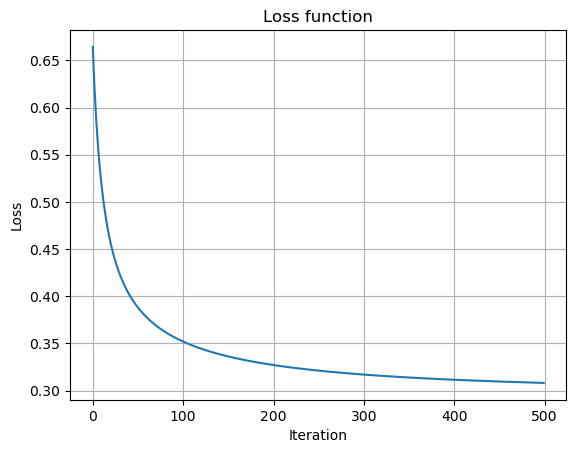

In [12]:
# Load the dataset
data_train = pd.read_csv("../data/optdigits.tra", header=None)
X_train = data_train.iloc[:, :64].to_numpy(dtype=float)
y_train = data_train.iloc[:, 64].to_numpy(dtype=int)

data_test = pd.read_csv("../data/optdigits.tes", header=None)
X_test = data_test.iloc[:, :64].to_numpy(dtype=float)
y_test = data_test.iloc[:, 64].to_numpy(dtype=int)

# Binarize the dataset
y_train_binary = np.where(y_train < 5, 0, 1)
y_test_binary = np.where(y_test < 5, 0, 1)

# Standardize the dataset
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0.0] = 1.0

X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) / std

# Use the Logistic Regression
lr = LogisticRegression(eta=0.1, n_iter=500, l2=1e-3)
lr.fit(X_train_std, y_train_binary)
y_pred = lr.predict(X_test_std)

# Evaluate the accuracy
accuracy = np.mean(y_pred == y_test_binary)
print(f"Final accuracy: {100.0 * accuracy:.2f}%")

# Plot the loss function
plt.figure()
plt.plot(lr.loss_)
plt.grid()
plt.title('Loss function')
plt.xlabel('Iteration')
plt.ylabel('Loss')

### Perceptron and Adaline <a id="Perceptron"></a>

#### Perceptron
The **perceptron**, proposed by Frank Rosenblatt in 1958, is one of the earliest trainable linear classifiers. For labels $d_n\in\{-1,+1\}$, it computes:
$$
s_n=\mathbf{w}^\top\mathbf{x}_n+b \qquad \text{and} \qquad y_n=\operatorname{sign}(s_n).
$$
The decision boundary $\mathbf{w}^\top\mathbf{x}+b=0$ is a hyperplane that divides the feature space into two half-spaces.

The perceptron update is a *mistake-driven* learning rule, not gradient descent through the discontinuous sign function. Whenever a sample is misclassified, the parameters are corrected according to:
$$
\mathbf{w}_{t+1} = \mathbf{w}_{t}+\eta(d_n-y_n)\mathbf{x}_n,
$$
$$
b_{t+1} = b_t+\eta(d_n-y_n),
$$
where $\eta>0$ is the learning rate.

In [13]:
class Perceptron:
    """Binary perceptron for labels -1 and +1."""

    def __init__(self, eta=0.01, n_iter=50, shuffle=True, random_state=1):
        self.eta = eta
        self.n_iter = n_iter
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)

        rng = np.random.default_rng(self.random_state)
        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        self.errors_ = []

        for _ in range(self.n_iter):
            indices = np.arange(X.shape[0])
            if self.shuffle:
                rng.shuffle(indices)

            errors = 0
            for i in indices:
                prediction = self.predict(X[i:i + 1])[0]
                update = self.eta * (y[i] - prediction)
                if update != 0.0:
                    self.w_ += update * X[i]
                    self.b_ += update
                    errors += 1
            self.errors_.append(errors)

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0.0, 1, -1)

For the binary digits experiment, the labels must be converted from $\{0,1\}$ to $\{-1,+1\}$:

In [14]:
y_train_pm = np.where(y_train_binary == 0, -1, 1)
y_test_pm = np.where(y_test_binary == 0, -1, 1)

pct = Perceptron(eta=0.01, n_iter=100, random_state=42)
pct.fit(X_train_std, y_train_pm)
y_pred = pct.predict(X_test_std)

accuracy = np.mean(y_pred == y_test_pm)
print(f"Final accuracy: {100.0 * accuracy:.2f}%")

Final accuracy: 83.92%


#### Adaline

**Adaline**, or *Adaptive Linear Neuron*, was introduced by Widrow and Hoff. Its structure resembles the perceptron, but the learning error is computed from the linear activation $s_n$ rather than from the thresholded class prediction.

For the squared-error loss $\frac{1}{2}(d_n-s_n)^2$, the stochastic update is:
$$
\mathbf{w}_{t+1} = \mathbf{w}_{t}+\eta(d_n-s_n)\mathbf{x}_n,
$$
$$
b_{t+1} = b_t+\eta(d_n-s_n).
$$
The following class uses the batch-gradient version of this rule:

In [15]:
class Adaline:
    """Adaptive linear neuron trained by batch gradient descent."""

    def __init__(self, eta=0.01, n_iter=100):
        self.eta = eta
        self.n_iter = n_iter

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        self.w_ = np.zeros(X.shape[1])
        self.b_ = 0.0
        self.loss_ = []
        n_samples = X.shape[0]

        for _ in range(self.n_iter):
            output = self.decision_function(X)
            error = y - output
            self.w_ += self.eta * (X.T @ error) / n_samples
            self.b_ += self.eta * error.mean()
            self.loss_.append(0.5 * np.mean(error**2))

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0.0, 1, -1)

This class can be used as follows:

In [16]:
ada = Adaline(eta=0.01, n_iter=300)
ada.fit(X_train_std, y_train_pm)
y_pred = ada.predict(X_test_std)

accuracy = np.mean(y_pred == y_test_pm)
print(f"Final accuracy: {100.0 * accuracy:.2f}%")

Final accuracy: 87.20%


### Single-layer perceptron <a id="SLP"></a>

A **single-layer perceptron** (SLP) contains a set of output neurons directly connected to the input features.

Let $\widetilde{\mathbf{x}}=[1,\mathbf{x}^\top]^\top\in\mathbb{R}^{M+1}$ include the bias input and let $\mathbf{W}\in\mathbb{R}^{K\times(M+1)}$ collect the parameters. The vector of logits is:
$$
\mathbf{s}=\mathbf{W}\widetilde{\mathbf{x}}.
$$
With independent sign activations ($\mathbf{y} = \text{sign}(\mathbf{s})$), each row of $\mathbf{W}$ defines a linear one-vs-rest discriminant. With a softmax\index{Softmax} output, the architecture becomes multinomial logistic regression:
$$
\mathbf{y}=\operatorname{softmax}(\mathbf{s})
\qquad \text{and} \qquad
\widehat{c}=\operatorname*{arg\,max}_{j}y_j.
$$
Every decision boundary between two classes remains linear because it is determined by equality of two logits.

In [17]:
class SoftmaxRegression:
    """Multiclass linear classifier with a softmax output."""

    def __init__(self, eta=0.05, n_iter=500, l2=0.0):
        self.eta = eta
        self.n_iter = n_iter
        self.l2 = l2

    @staticmethod
    def _softmax(Z):
        Z = Z - Z.max(axis=1, keepdims=True)
        exp_Z = np.exp(Z)
        return exp_Z / exp_Z.sum(axis=1, keepdims=True)

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y)
        self.classes_, y_index = np.unique(y, return_inverse=True)

        n_samples, n_features = X.shape
        n_classes = len(self.classes_)
        Y = np.eye(n_classes)[y_index]

        self.W_ = np.zeros((n_features, n_classes))
        self.b_ = np.zeros(n_classes)
        self.loss_ = []

        for _ in range(self.n_iter):
            probabilities = self._softmax(X @ self.W_ + self.b_)
            error = probabilities - Y

            grad_W = (X.T @ error) / n_samples + self.l2 * self.W_
            grad_b = error.mean(axis=0)
            self.W_ -= self.eta * grad_W
            self.b_ -= self.eta * grad_b

            probabilities = self._softmax(X @ self.W_ + self.b_)
            probabilities = np.clip(probabilities, 1e-12, 1.0)
            data_loss = -np.mean(np.sum(Y * np.log(probabilities), axis=1))
            self.loss_.append(
                data_loss + 0.5 * self.l2 * np.sum(self.W_**2)
            )

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return self._softmax(X @ self.W_ + self.b_)

    def predict(self, X):
        indices = np.argmax(self.predict_proba(X), axis=1)
        return self.classes_[indices]

### Multilayer perceptron <a id="MLP"></a>

A **multilayer perceptron** (MLP) inserts one or more hidden layers between the input and output layers. Let $N_l$ denote the number of units in layer $l$, with $N_0$ input features and $N_L$ outputs.

For one input sample, *forward propagation* is described by:
$$
\mathbf{s}^{(l)} = \mathbf{W}^{(l)}\mathbf{x}^{(l-1)}+\mathbf{b}^{(l)},
$$
$$
\mathbf{x}^{(l)} = \boldsymbol{\varphi}^{(l)}\!\left(\mathbf{s}^{(l)}\right),\qquad l=1,\ldots,L,
$$
where $\mathbf{x}^{(0)}=\mathbf{x}$ and $\mathbf{y}=\mathbf{x}^{(L)}$. The composition of affine transformations and nonlinear activations allows the network to represent nonlinear mappings.

Training consists of a *forward* pass followed by a *backward* pass. Suppose that the instantaneous squared-error loss is:
$$
\mathcal{L}_n=\frac{1}{2}\|\mathbf{d}_n-\mathbf{y}_n\|^2.
$$
Define $\boldsymbol{\delta}^{(l)}$ as the negative derivative of the loss with respect to the pre-activation vector $\mathbf{s}^{(l)}$. At the output layer, we obtain:
$$
\boldsymbol{\delta}^{(L)}
=(\mathbf{d}-\mathbf{y})
\odot
\boldsymbol{\varphi}^{(L)\prime}(\mathbf{s}^{(L)}),
$$
where $\odot$ denotes element-wise multiplication. For a hidden layer, we have:
$$
\boldsymbol{\delta}^{(l)} = \left[(\mathbf{W}^{(l+1)})^\top
\boldsymbol{\delta}^{(l+1)}\right]
\odot
\boldsymbol{\varphi}^{(l)\prime}(\mathbf{s}^{(l)}),
\qquad l=L-1,\ldots,1.
$$
The parameters are then updated by:
$$
\mathbf{W}^{(l)} \leftarrow\mathbf{W}^{(l)}+\eta\boldsymbol{\delta}^{(l)}(\mathbf{x}^{(l-1)})^\top,
$$
$$
\mathbf{b}^{(l)} \leftarrow\mathbf{b}^{(l)}+\eta\boldsymbol{\delta}^{(l)}.
$$
This recursive application of the chain rule is the **backpropagation algorithm**. With a softmax output and cross-entropy loss, the output signal simplifies to $\boldsymbol{\delta}^{(L)}=\mathbf{d}-\mathbf{y}$.

In [18]:
class NeuralNetMLP:
    """One-hidden-layer multilayer perceptron classifier."""

    def __init__(
        self,
        n_hidden=30,
        l2=0.0,
        epochs=100,
        eta=1e-3,
        shuffle=True,
        minibatch_size=32,
        seed=None,
        early_stopping=False,
        patience=20,
        tol=1e-5,
        verbose=False,
    ):

        self.n_hidden = n_hidden
        self.l2 = l2
        self.epochs = epochs
        self.eta = eta
        self.shuffle = shuffle
        self.minibatch_size = minibatch_size
        self.seed = seed
        self.early_stopping = early_stopping
        self.patience = patience
        self.tol = tol
        self.verbose = verbose

        self.rng = np.random.default_rng(seed)

    @staticmethod
    def _sigmoid(z):
        """Numerically stable sigmoid."""
        z = np.clip(z, -250.0, 250.0)
        return 1.0 / (1.0 + np.exp(-z))

    @staticmethod
    def _softmax(z):
        """Numerically stable row-wise softmax."""
        z = z - np.max(z, axis=1, keepdims=True)
        exp_z = np.exp(z)
        return exp_z / np.sum(exp_z, axis=1, keepdims=True)

    def _initialize_parameters(self, n_features, n_classes):
        """Xavier initialization."""
        hidden_limit = np.sqrt(6.0 / (n_features + self.n_hidden))
        output_limit = np.sqrt(6.0 / (self.n_hidden + n_classes))

        self.w_h = self.rng.uniform(
            -hidden_limit,
            hidden_limit,
            size=(n_features, self.n_hidden),
        )
        self.b_h = np.zeros(self.n_hidden)

        self.w_out = self.rng.uniform(
            -output_limit,
            output_limit,
            size=(self.n_hidden, n_classes),
        )
        self.b_out = np.zeros(n_classes)

    def _forward(self, X):
        """Forward propagation."""
        z_h = X @ self.w_h + self.b_h
        a_h = self._sigmoid(z_h)

        z_out = a_h @ self.w_out + self.b_out
        a_out = self._softmax(z_out)

        return z_h, a_h, z_out, a_out

    def _encode_labels(self, y):
        """Convert original labels into integer indices."""
        encoded = np.empty(len(y), dtype=int)

        for i, label in enumerate(y):
            if label not in self.class_to_index_:
                raise ValueError(f"Unknown class label: {label}")
            encoded[i] = self.class_to_index_[label]

        return encoded

    def _loss(self, probabilities, y_encoded):
        """Cross-entropy loss with L2 regularization."""
        eps = np.finfo(float).eps

        correct_probabilities = probabilities[np.arange(len(y_encoded)), y_encoded]

        cross_entropy = -np.mean(np.log(np.clip(correct_probabilities, eps, 1.0)))

        regularization = (
            0.5  * self.l2 / self.n_train_
            * (np.sum(self.w_h**2) + np.sum(self.w_out**2))
        )

        return cross_entropy + regularization

    @staticmethod
    def _accuracy(probabilities, y_encoded):
        predictions = np.argmax(probabilities, axis=1)
        return np.mean(predictions == y_encoded)

    def _save_parameters(self):
        return {
            "w_h": self.w_h.copy(),
            "b_h": self.b_h.copy(),
            "w_out": self.w_out.copy(),
            "b_out": self.b_out.copy(),
        }

    def _restore_parameters(self, parameters):
        self.w_h = parameters["w_h"]
        self.b_h = parameters["b_h"]
        self.w_out = parameters["w_out"]
        self.b_out = parameters["b_out"]

    def fit(
        self,
        X_train,
        y_train,
        X_valid=None,
        y_valid=None,
    ):
        """Train the neural network."""
        X_train = np.asarray(X_train, dtype=float)
        y_train = np.asarray(y_train)

        self.classes_, y_train_encoded = np.unique(
            y_train,
            return_inverse=True,
        )

        self.class_to_index_ = {
            label: index
            for index, label in enumerate(self.classes_)
        }

        self.n_features_in_ = X_train.shape[1]
        self.n_outputs_ = len(self.classes_)
        self.n_train_ = len(X_train)

        if X_valid is not None:
            X_valid = np.asarray(X_valid, dtype=float)
            y_valid = np.asarray(y_valid)
            y_valid_encoded = self._encode_labels(y_valid)
        else:
            y_valid_encoded = None

        self.rng = np.random.default_rng(self.seed)
        self._initialize_parameters(
            self.n_features_in_,
            self.n_outputs_,
        )

        self.eval_ = {
            "train_loss": [],
            "train_acc": [],
        }

        if X_valid is not None:
            self.eval_["valid_loss"] = []
            self.eval_["valid_acc"] = []

        indices = np.arange(self.n_train_)

        best_loss = np.inf
        best_parameters = None
        epochs_without_improvement = 0

        for epoch in range(self.epochs):

            if self.shuffle:
                self.rng.shuffle(indices)

            for start in range(
                0,
                self.n_train_,
                self.minibatch_size,
            ):
                batch_indices = indices[start:start + self.minibatch_size]

                X_batch = X_train[batch_indices]
                y_batch = y_train_encoded[batch_indices]

                batch_size = len(X_batch)

                _, a_h, _, probabilities = self._forward(X_batch)

                # Softmax-cross-entropy derivative.
                delta_out = probabilities.copy()
                delta_out[np.arange(batch_size), y_batch] -= 1.0
                delta_out /= batch_size

                grad_w_out = a_h.T @ delta_out
                grad_b_out = np.sum(delta_out, axis=0)

                delta_h = (delta_out @ self.w_out.T) * a_h * (1.0 - a_h)

                grad_w_h = X_batch.T @ delta_h
                grad_b_h = np.sum(delta_h, axis=0)

                # Regularize weights, but not biases.
                reg_scale = self.l2 / self.n_train_

                grad_w_out += (reg_scale * self.w_out)
                grad_w_h += reg_scale * self.w_h

                # Gradient-descent update.
                self.w_out -= self.eta * grad_w_out
                self.b_out -= self.eta * grad_b_out

                self.w_h -= self.eta * grad_w_h
                self.b_h -= self.eta * grad_b_h

            # Training metrics.
            train_probabilities = self._forward(X_train)[-1]

            train_loss = self._loss(train_probabilities, y_train_encoded)
            train_acc = self._accuracy(train_probabilities, y_train_encoded)

            self.eval_["train_loss"].append(train_loss)
            self.eval_["train_acc"].append(train_acc)

            # Validation metrics.
            if X_valid is not None:
                valid_probabilities = self._forward(X_valid)[-1]

                valid_loss = self._loss(valid_probabilities, y_valid_encoded)
                valid_acc = self._accuracy(valid_probabilities, y_valid_encoded)

                self.eval_["valid_loss"].append(valid_loss)
                self.eval_["valid_acc"].append(valid_acc)

                monitored_loss = valid_loss
            else:
                valid_loss = None
                valid_acc = None
                monitored_loss = train_loss

            if self.verbose:
                interval = max(1, self.epochs // 10)

                if epoch == 0 or (epoch + 1) % interval == 0:
                    message = (
                        f"Epoch {epoch + 1}/{self.epochs} "
                        f"- loss: {train_loss:.4f} "
                        f"- acc: {train_acc:.4f}"
                    )

                    if valid_loss is not None:
                        message += (
                            f" - val_loss: {valid_loss:.4f}"
                            f" - val_acc: {valid_acc:.4f}"
                        )

                    print(message)

            # Optional early stopping.
            if monitored_loss < best_loss - self.tol:
                best_loss = monitored_loss
                best_parameters = self._save_parameters()
                epochs_without_improvement = 0
            else:
                epochs_without_improvement += 1

            self.n_epochs_ = epoch + 1

            if (
                self.early_stopping
                and epochs_without_improvement
                >= self.patience
            ):
                if self.verbose:
                    print(
                        "Early stopping after "
                        f"{self.n_epochs_} epochs."
                    )
                break

        if (
            self.early_stopping
            and best_parameters is not None
        ):
            self._restore_parameters(best_parameters)

        return self

    def predict_proba(self, X):
        """Return the estimated class probabilities."""
        self._check_is_fitted()

        X = np.asarray(X, dtype=float)

        return self._forward(X)[-1]

    def predict(self, X):
        """Return predicted class labels."""
        probabilities = self.predict_proba(X)
        encoded_predictions = np.argmax(
            probabilities,
            axis=1,
        )
        return self.classes_[encoded_predictions]

    def score(self, X, y):
        """Return the classification accuracy."""
        y = np.asarray(y)
        predictions = self.predict(X)
        return np.mean(predictions == y)

    def _check_is_fitted(self):
        required_attributes = (
            "classes_",
            "w_h",
            "b_h",
            "w_out",
            "b_out",
        )

        if not all(
            hasattr(self, name)
            for name in required_attributes
        ):
            raise RuntimeError(
                "The model must be fitted before prediction."
            )

The class can be used as:

Accuracy = 69.91%


Text(0, 0.5, 'Loss')

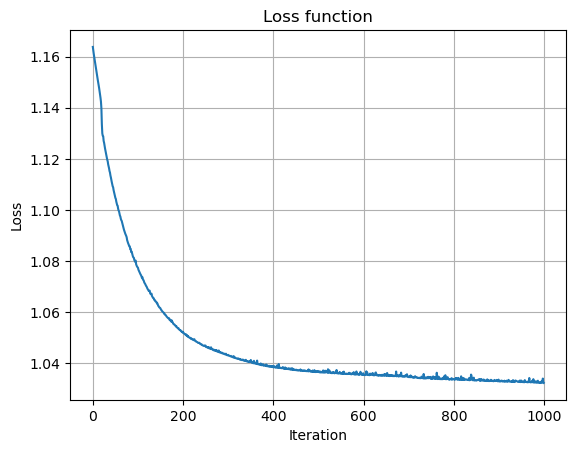

In [19]:
rng = np.random.default_rng(42)
data = load_dataset("penguins")
columns = [
    "species",
    "bill_length_mm",
    "bill_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

data = data[columns].dropna()
idx = rng.permutation(len(data))
data = data.iloc[idx].reset_index(drop=True)

X = data.iloc[:, 1:].to_numpy(dtype=float)
label_map = {"Adelie": 0, "Chinstrap": 1, "Gentoo": 2}
y = data["species"].map(label_map).to_numpy(dtype=int)

n_train = int(0.67 * len(data))
X_train, X_test = X[:n_train], X[n_train:]
y_train, y_test = y[:n_train], y[n_train:]


mlp = NeuralNetMLP(
    n_hidden=400,
    minibatch_size=16,
    eta=5e-6,
    epochs=1000,
    l2=0.1,
)
mlp.fit(X_train, y_train)
y_pred = mlp.predict(X_test)

accuracy = np.mean(y_pred == y_test)
print(f"Accuracy = {100.0 * accuracy:.2f}%")

# Plot the loss function
plt.figure()
plt.plot(mlp.eval_["train_loss"])
plt.grid()
plt.title('Loss function')
plt.xlabel('Iteration')
plt.ylabel('Loss')

### Support Vector Machines <a id="SVM"></a>

A **support vector machine** (SVM) is a *maximum-margin* classifier. In the binary linear case, it searches for a separating hyperplane whose distance from the closest training samples is as large as possible.

Consider a training set $\mathcal{T}=\{(\mathbf{x}_i,d_i)\}_{i=1}^{N}$ with $d_i\in\{-1,+1\}$. A linear classifier uses the discriminant:
$$
f(\mathbf{x})=\mathbf{w}^\top\mathbf{x}+b,
$$
and predicts $\operatorname{sign}(f(\mathbf{x}))$. For linearly separable data, the parameters can be scaled so that:
$$
d_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq1,
\qquad i=1,\ldots,N.
$$
The samples for which equality holds are the **support vectors**.

The perpendicular distance of a point $\mathbf{x}$ from the hyperplane is:
$$
\frac{|\mathbf{w}^\top\mathbf{x}+b|}{\|\mathbf{w}\|}.
$$
Consequently, each supporting hyperplane is at distance $1/\|\mathbf{w}\|$ from the decision boundary, and the total margin is:
$$
\rho=\frac{2}{\|\mathbf{w}\|}.
$$
Maximizing the margin is therefore equivalent to solving the convex optimization problem:
$$
\min_{\mathbf{w},b}\quad \frac{1}{2}\|\mathbf{w}\|^2,
$$
$$
\text{s.t.}\quad d_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq1,
\quad i=1,\ldots,N.
$$
Introducing non-negative Lagrange multipliers $\lambda_i$, the Lagrangian is:
$$
\mathcal{L}(\mathbf{w},b,\boldsymbol{\lambda})= \frac{1}{2}\|\mathbf{w}\|^2
+\sum_{i=1}^{N}\lambda_i \left[1-d_i(\mathbf{w}^\top\mathbf{x}_i+b)\right].
$$

Real datasets are rarely perfectly separable. The **soft-margin SVM** introduces slack variables $\xi_i\geq0$:
$$
d_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq1-\xi_i.
$$
The value of $\xi_i$ describes the type of margin violation:
- $\xi_i=0$: the point is on or outside the correct margin;
- $0<\xi_i<1$: the point is inside the margin but still correctly classified;
- $\xi_i=1$: the point lies on the decision boundary;
- $\xi_i>1$: the point is misclassified.

The soft-margin primal problem is:
$$
\min_{\mathbf{w},b,\boldsymbol{\xi}}\quad \frac{1}{2}\|\mathbf{w}\|^2+C\sum_{i=1}^{N}\xi_i,
$$
$$
\text{s.t.} \quad d_i(\mathbf{w}^\top\mathbf{x}_i+b)\geq1-\xi_i,
$$
$$
\qquad \quad \xi_i\geq0, \qquad i=1,\ldots,N.
$$
The parameter $C>0$ controls the trade-off between a wide margin and violations of the margin constraints. A large $C$ penalizes violations strongly, whereas a small $C$ permits more violations in exchange for stronger regularization.

The primal problem can also be written using the **hinge loss**:
$$
\min_{\mathbf{w},b}\frac{\lambda}{2}\|\mathbf{w}\|^2 + \frac{1}{N}\sum_{i=1}^{N} \max\{0,1-d_i f(\mathbf{x}_i)\},
$$
where $f(\mathbf{x})=\mathbf{w}^\top\mathbf{x}+b$. Under this scaling, $\lambda$ is inversely related to $C$. The bias is not included in the $L_2$ regularizer.

Because the hinge loss is not differentiable at one point, optimization uses a subgradient. For one sample, the parameter update is:
$$
\mathbf{w}\leftarrow
\begin{cases}
\mathbf{w}-\eta(\lambda\mathbf{w}-d_i\mathbf{x}_i),
& d_i f(\mathbf{x}_i)<1,\\
\mathbf{w}-\eta\lambda\mathbf{w},
& d_i f(\mathbf{x}_i)\geq1,
\end{cases}
$$
while the bias is updated only when the margin is violated.

The following mini-batch implementation correctly excludes the bias from regularization and processes the final, possibly incomplete, mini-batch:

In [20]:
class LinearSVM:
    """Linear soft-margin SVM trained by mini-batch subgradient descent."""

    def __init__(self, eta=0.01, epochs=100, batch_size=32,
                 l2=0.01, shuffle=True, random_state=42):
        self.eta = eta
        self.epochs = epochs
        self.batch_size = batch_size
        self.l2 = l2
        self.shuffle = shuffle
        self.random_state = random_state

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        rng = np.random.default_rng(self.random_state)
        n_samples, n_features = X.shape
        self.w_ = np.zeros(n_features)
        self.b_ = 0.0
        self.loss_ = []

        for _ in range(self.epochs):
            indices = np.arange(n_samples)
            if self.shuffle:
                rng.shuffle(indices)

            for start in range(0, n_samples, self.batch_size):
                batch = indices[start:start + self.batch_size]
                Xb, yb = X[batch], y[batch]
                batch_size = len(batch)

                scores = Xb @ self.w_ + self.b_
                active = yb * scores < 1.0

                grad_w = self.l2 * self.w_
                grad_b = 0.0
                if np.any(active):
                    grad_w -= (Xb[active].T @ yb[active]) / batch_size
                    grad_b -= yb[active].sum() / batch_size

                self.w_ -= self.eta * grad_w
                self.b_ -= self.eta * grad_b

            margins = y * (X @ self.w_ + self.b_)
            hinge = np.maximum(0.0, 1.0 - margins).mean()
            regularizer = 0.5 * self.l2 * np.dot(self.w_, self.w_)
            self.loss_.append(regularizer + hinge)

        return self

    def decision_function(self, X):
        X = np.asarray(X, dtype=float)
        return X @ self.w_ + self.b_

    def predict(self, X):
        return np.where(self.decision_function(X) >= 0.0, 1, -1)

The implementation can be tested using the binarized digits dataset after a data standardization.

Final accuracy: 87.98%


Text(0, 0.5, 'Loss')

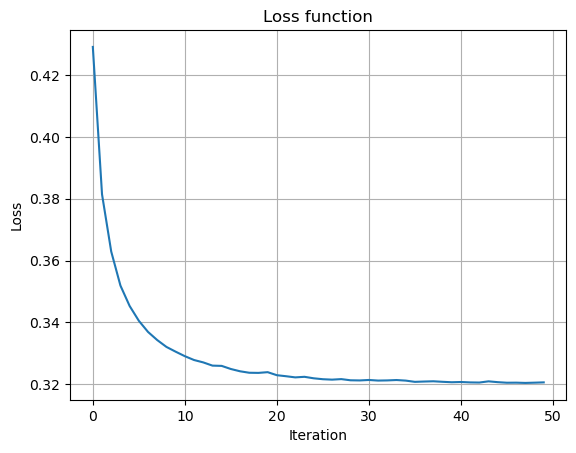

In [21]:
# Load the dataset
data_train = pd.read_csv("../data/optdigits.tra", header=None)
X_train = data_train.iloc[:, :64].to_numpy(dtype=float)
y_train = data_train.iloc[:, 64].to_numpy(dtype=int)

data_test = pd.read_csv("../data/optdigits.tes", header=None)
X_test = data_test.iloc[:, :64].to_numpy(dtype=float)
y_test = data_test.iloc[:, 64].to_numpy(dtype=int)

# Binarize the dataset
y_train_binary = np.where(y_train < 5, 0, 1)
y_test_binary = np.where(y_test < 5, 0, 1)

# Convert labels to -1 and +1
y_train_pm = np.where(y_train_binary == 0, -1, 1)
y_test_pm = np.where(y_test_binary == 0, -1, 1)

# Standardize the dataset
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)
std[std == 0.0] = 1.0

X_train_std = (X_train - mean) / std
X_test_std = (X_test - mean) / std

# Use the Linear SVM
svm = LinearSVM(eta=0.01, epochs=50, batch_size=32)
svm.fit(X_train_std, y_train_pm)
y_pred = svm.predict(X_test_std)

# Evaluate the accuracy
accuracy = np.mean(y_pred == y_test_pm)
print(f"Final accuracy: {100.0 * accuracy:.2f}%")

# Plot the loss function
plt.figure()
plt.plot(svm.loss_)
plt.grid()
plt.title('Loss function')
plt.xlabel('Iteration')
plt.ylabel('Loss')

A linear SVM cannot directly represent nonlinear decision boundaries. One possibility is to map the input into a **feature space** through:
$$
\boldsymbol{\Phi}:\mathbb{R}^{M}\rightarrow\mathcal{H}
$$
and construct a linear separator in $\mathcal{H}$. The feature space may be high-dimensional or even infinite-dimensional. 

In feature space, the decision function is:
$$
f(\mathbf{x})
=\mathbf{w}^\top\boldsymbol{\Phi}(\mathbf{x})+b.
$$

Implementing a reliable kernel SVM requires a constrained quadratic-programming or sequential-minimal-optimization solver. For this reason, the practical implementation is deferred to the next chapter, where Scikit-learn is used.